# Linear Algebra & Calculus on the California Housing Dataset

This notebook demonstrates vectors, matrices, dot product, eigenvalues/eigenvectors, derivatives, gradients, chain rule, backpropagation intuition, and gradient descent using the California Housing dataset.

**Target:** `MedInc`  
**Features:** the other 7 numerical columns.

In [1]:
# 1. Upload the dataset
from google.colab import files

uploaded = files.upload()

Saving california_housing.csv to california_housing (1).csv


In [2]:
# 2. Import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("california_housing.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (20640, 8)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 1. Vectors

One observation can be represented as a vector. Each element corresponds to one feature.

In [3]:
features = [
    "HouseAge", "AveRooms", "AveBedrms", "Population",
    "AveOccup", "Latitude", "Longitude"
]
target = "MedInc"

X = df[features].values
y = df[target].values

x1 = X[0]

print("First observation as a vector:")
print(x1)
print("\nVector dimension:", len(x1))

First observation as a vector:
[  41.            6.98412698    1.02380952  322.            2.55555556
   37.88       -122.23      ]

Vector dimension: 7


## 2. Matrices

`X` is a matrix where rows represent observations and columns represent features.

In [4]:
print("Feature matrix shape:", X.shape)
print("\nFirst 5 rows:")
print(X[:5])

Feature matrix shape: (20640, 7)

First 5 rows:
[[ 4.10000000e+01  6.98412698e+00  1.02380952e+00  3.22000000e+02
   2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 2.10000000e+01  6.23813708e+00  9.71880492e-01  2.40100000e+03
   2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 5.20000000e+01  8.28813559e+00  1.07344633e+00  4.96000000e+02
   2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.20000000e+01  5.81735160e+00  1.07305936e+00  5.58000000e+02
   2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 5.20000000e+01  6.28185328e+00  1.08108108e+00  5.65000000e+02
   2.18146718e+00  3.78500000e+01 -1.22250000e+02]]


## 3. Standardization

The features have different scales, so we standardize them before gradient descent and PCA.

In [5]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

print("First 5 standardized rows:")
print(X_scaled[:5])

First 5 standardized rows:
[[ 0.98214266  0.62855945 -0.15375759 -0.9744286  -0.04959654  1.05254828
  -1.32783522]
 [-0.60701891  0.32704136 -0.26333577  0.86143887 -0.09251223  1.04318455
  -1.32284391]
 [ 1.85618152  1.15562047 -0.04901636 -0.82077735 -0.02584253  1.03850269
  -1.33282653]
 [ 1.85618152  0.15696608 -0.04983292 -0.76602806 -0.0503293   1.03850269
  -1.33781784]
 [ 1.85618152  0.3447108  -0.03290586 -0.75984669 -0.08561576  1.03850269
  -1.33781784]]


## 4. Dot Product

For one observation, a linear model computes:

`prediction = x · w + b`

The dot product combines feature values with their corresponding weights.

In [6]:
weights = np.array([0.2, 0.3, 0.1, -0.1, -0.2, 0.4, -0.3])
bias = 0.5

prediction = np.dot(X_scaled[0], weights) + bias

print("Dot product prediction:", prediction)

Dot product prediction: 1.7963526553276297


## 5. Matrix Multiplication

Matrix multiplication calculates predictions for all observations:

`Y_hat = XW + b`

In [7]:
predictions = np.dot(X_scaled, weights) + bias

print("First 10 predictions:")
print(predictions[:10])
print("\nPrediction shape:", predictions.shape)

First 10 predictions:
[1.79635266 1.1968606  2.11551608 1.81675793 1.8812132  1.71586153
 1.64258749 1.65058945 1.43498664 1.61427224]

Prediction shape: (20640,)


## 6. Eigenvalues and Eigenvectors

We calculate the covariance matrix and then its eigenvalues/eigenvectors. Eigenvalues indicate how much variance is associated with each principal direction.

In [8]:
cov_matrix = np.cov(X_scaled, rowvar=False)

print("Covariance matrix:")
print(cov_matrix)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort from largest to smallest
indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Covariance matrix:
[[ 1.00004845 -0.15328485 -0.07775105 -0.29625859  0.013192    0.01117321
  -0.10820206]
 [-0.15328485  1.00004845  0.84766239 -0.07221635 -0.00485253  0.10639412
  -0.02754139]
 [-0.07775105  0.84766239  1.00004845 -0.06620061 -0.0061815   0.06972451
   0.01334504]
 [-0.29625859 -0.07221635 -0.06620061  1.00004845  0.06986612 -0.10879002
   0.09977806]
 [ 0.013192   -0.00485253 -0.0061815   0.06986612  1.00004845  0.0023663
   0.00247594]
 [ 0.01117321  0.10639412  0.06972451 -0.10879002  0.0023663   1.00004845
  -0.92470924]
 [-0.10820206 -0.02754139  0.01334504  0.09977806  0.00247594 -0.92470924
   1.00004845]]

Eigenvalues:
[2.02239508 1.8333078  1.25746788 1.00310444 0.6698322  0.1477758
 0.06645596]

Eigenvectors:
[[-0.03330753  0.24407559  0.65127946 -0.22317612 -0.67379512 -0.06975654
  -0.08049452]
 [-0.38728373 -0.57950819  0.04941891 -0.03001526 -0.05595467 -0.71196587
  -0.02849722]
 [-0.36385547 -0.5853375   0.1026032  -0.04990992 -0.15958383  0.6929462

In [9]:
explained_variance = eigenvalues / np.sum(eigenvalues) * 100

print("Variance explained:")
for i, value in enumerate(explained_variance, start=1):
    print(f"PC{i}: {value:.2f}%")

Variance explained:
PC1: 28.89%
PC2: 26.19%
PC3: 17.96%
PC4: 14.33%
PC5: 9.57%
PC6: 2.11%
PC7: 0.95%


## 7. PCA Using Eigenvectors

The first two eigenvectors define the first two principal components.

In [10]:
principal_components = eigenvectors[:, :2]
X_pca = np.dot(X_scaled, principal_components)

print("Original dimensions:", X_scaled.shape[1])
print("Reduced dimensions:", X_pca.shape[1])
print("\nFirst 5 PCA representations:")
print(X_pca[:5])

Original dimensions: 7
Reduced dimensions: 2

First 5 PCA representations:
[[-1.78427838  0.89841752]
 [-1.23461181  0.60027952]
 [-2.02185045  0.73047908]
 [-1.62811242  1.3072192 ]
 [-1.70642649  1.18785867]]


## 8. Derivative of Mean Squared Error

The loss is:

`L = (1/n) Σ(y_hat - y)^2`

Its derivative with respect to the prediction is:

`dL/dy_hat = (2/n)(y_hat - y)`

In [11]:
n = len(y_scaled)

error = predictions - y_scaled
dL_dprediction = (2 / n) * error

print("First 10 errors:")
print(error[:10])

print("\nFirst 10 derivative values:")
print(dL_dprediction[:10])

First 10 errors:
[-0.5484131  -1.13537736  0.33281668  0.88379042  1.8940942   1.62841489
  1.7539538   2.0457261   2.37734579  1.70874182]

First 10 derivative values:
[-5.31408046e-05 -1.10017186e-04  3.22496782e-05  8.56386066e-05
  1.83536260e-04  1.57792140e-04  1.69956763e-04  1.98229274e-04
  2.30362964e-04  1.65575757e-04]


## 9. Gradient and Chain Rule

For the model `y_hat = Xw + b`, the chain rule gives:

`gradient_w = X.T @ dL/dy_hat`

This is the key mathematical idea behind backpropagation.

In [12]:
gradient_weights = np.dot(X_scaled.T, dL_dprediction)
gradient_bias = np.sum(dL_dprediction)

print("Gradient of weights:")
for feature, gradient in zip(features, gradient_weights):
    print(f"{feature}: {gradient:.6f}")

print("\nGradient of bias:", gradient_bias)

Gradient of weights:
HouseAge: 0.658381
AveRooms: 0.172441
AveBedrms: 0.865036
Population: -0.559570
AveOccup: -0.449969
Latitude: 1.617474
Longitude: -1.387459

Gradient of bias: 1.0000000000000042


## 10. Gradient Descent and Backpropagation

The forward pass computes predictions and loss. Backpropagation uses derivatives and the chain rule to calculate gradients. Gradient descent then updates the weights.

In [13]:
weights = np.zeros(X_scaled.shape[1])
bias = 0.0

learning_rate = 0.01
epochs = 1000
loss_history = []

for epoch in range(epochs):
    # Forward pass
    predictions = np.dot(X_scaled, weights) + bias
    error = predictions - y_scaled
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Backpropagation
    dL_dprediction = (2 / n) * error
    gradient_weights = np.dot(X_scaled.T, dL_dprediction)
    gradient_bias = np.sum(dL_dprediction)

    # Gradient descent
    weights -= learning_rate * gradient_weights
    bias -= learning_rate * gradient_bias

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.6f}")

Epoch 0: Loss = 1.000000
Epoch 100: Loss = 0.725841
Epoch 200: Loss = 0.589369
Epoch 300: Loss = 0.511894
Epoch 400: Loss = 0.467356
Epoch 500: Loss = 0.441421
Epoch 600: Loss = 0.426081
Epoch 700: Loss = 0.416833
Epoch 800: Loss = 0.411133
Epoch 900: Loss = 0.407533


## 11. Loss Curve

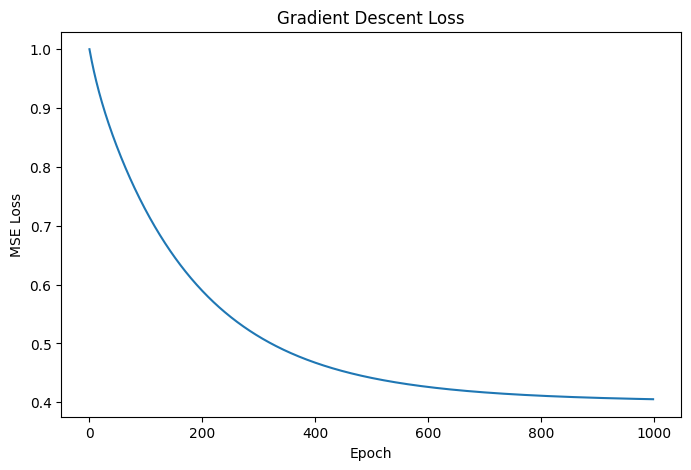

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Loss")
plt.show()

## 12. Final Model Parameters

In [15]:
print("Final model weights:\n")

for feature, weight in zip(features, weights):
    print(f"{feature}: {weight:.4f}")

print("\nFinal bias:", round(bias, 4))

Final model weights:

HouseAge: -0.0589
AveRooms: 1.2999
AveBedrms: -1.1101
Population: -0.0081
AveOccup: 0.0223
Latitude: -0.6184
Longitude: -0.5298

Final bias: -0.0


## 13. Actual vs Predicted Values

The predictions are converted back to the original `MedInc` scale.

In [16]:
final_predictions_scaled = np.dot(X_scaled, weights) + bias
final_predictions = final_predictions_scaled * y_std + y_mean

print("Actual vs Predicted:\n")

for i in range(10):
    print(
        f"Actual: {y[i]:.2f}   "
        f"Predicted: {final_predictions[i]:.2f}"
    )

Actual vs Predicted:

Actual: 8.33   Predicted: 5.75
Actual: 8.30   Predicted: 5.39
Actual: 7.26   Predicted: 6.75
Actual: 5.64   Predicted: 4.29
Actual: 3.85   Predicted: 4.72
Actual: 4.04   Predicted: 3.10
Actual: 3.66   Predicted: 3.95
Actual: 3.12   Predicted: 3.32
Actual: 2.08   Predicted: 2.66
Actual: 3.69   Predicted: 3.81


## Conclusion

This notebook applied the mathematical foundations of machine learning to the California Housing dataset:

- **Vectors:** represent individual observations.
- **Matrices:** represent the feature dataset.
- **Dot product:** produces a weighted prediction.
- **Eigenvalues/eigenvectors:** identify important directions of variation and enable PCA.
- **Derivatives:** measure how loss changes with predictions.
- **Gradients:** measure how loss changes with model parameters.
- **Chain rule:** connects derivatives through the model and forms the basis of backpropagation.
- **Gradient descent:** uses gradients to update weights and reduce loss.